# Static optimized vs. DAPRO vs. infinite-budget oracle

This notebook tests whether finite-budget DAPRO approaches `oracle_survival_calibration` while the static optimized baseline remains more variable and farther from the requested LPB coverage. Comparisons are paired by seed and target coverage.

In [17]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Match the sufficient-budget DAPRO setup used by visualize_dapro_lpb_budget.ipynb.
config = {
    "dataset_name": "dataset_toxicity",
    "dataset_setup": "attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify",
    "budget_per_sample": 20.0,
    "cal_size": 3000,
    "tau_prior": 0.56,
    "is_real": True,
}
FOCUS_TARGET = 0.90
MIN_TARGET = 0.899
MAX_TARGET = 0.9001

METHOD_CANDIDATES = {
    "Optimized": ["optimized", "calibration_optimized_allocation"],
    "DAPRO": ["calibration_projected_optimization_platt_prob_allocation"],
    "Oracle": ["oracle_survival_calibration"],
}
METHOD_ORDER = ["Optimized", "DAPRO", "Oracle"]
COLORS = {"Optimized": "#D55E00", "DAPRO": "#0072B2", "Oracle": "#000000"}

m_upper_bound = 200 if config["is_real"] else 20
gamma = m_upper_bound / config["budget_per_sample"]
experiment_signature = (
    f'{config["dataset_name"]}_{config["dataset_setup"]}_'
    f'{config["budget_per_sample"]}_{config["cal_size"]}_'
    f'{config["tau_prior"]}_{np.round(gamma, 3)}'
)
csv_path = (
    PROJECT_ROOT / "results" / "merged_calibration_dfs" /
    experiment_signature / "all_df.csv"
)
csv_path


PosixPath('/Users/shai.feldman/Documents/Projects/dapro_rebuttal/results/merged_calibration_dfs/dataset_toxicity_attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify_20.0_3000_0.56_10.0/all_df.csv')

In [18]:
if not csv_path.exists():
    raise FileNotFoundError(f"Merged LPB results were not found at {csv_path}")

all_df = pd.read_csv(csv_path)
required_columns = {"seed", "calibration_name", "coverage", "target_coverage"}
missing_columns = required_columns.difference(all_df.columns)
if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")

available_methods = set(all_df["calibration_name"].dropna().astype(str))
resolved_methods = {
    label: next((name for name in candidates if name in available_methods), None)
    for label, candidates in METHOD_CANDIDATES.items()
}
missing_methods = [label for label, name in resolved_methods.items() if name is None]
analysis_ready = not missing_methods

if missing_methods:
    missing_names = ", ".join(missing_methods)
    display(Markdown(
        f"> **Results unavailable:** the merged CSV is missing {missing_names}. "
        "Re-run LPB construction and merging after generating "
        "`oracle_survival_calibration`; then re-run this notebook. No proxy data are used."
    ))
else:
    display(pd.Series(resolved_methods, name="calibration_name").rename_axis("display_name").to_frame())


,calibration_name
display_name,
Optimized,calibration_optimized_allocation
DAPRO,calibration_projected_optimization_platt_prob_...
Oracle,oracle_survival_calibration


In [23]:
if not analysis_ready:
    print("Summary table skipped until all three methods are available.")
else:
    focus_summary = (
        target_stats.loc[np.isclose(target_stats["target_coverage"], FOCUS_TARGET)]
        .set_index("Method")
        .reindex(METHOD_ORDER)
    )

    oracle_std = focus_summary.loc["Oracle", "coverage_std_pp"]
    oracle_abs_error = focus_summary.loc["Oracle", "mae_pp"]

    focus_summary["Std / oracle"] = (
        focus_summary["coverage_std_pp"] / oracle_std
    )
    focus_summary["Absolute coverage error / oracle"] = (
        focus_summary["mae_pp"] / oracle_abs_error
    )

    focus_summary = focus_summary.rename(columns={
        "mean_coverage_pct": "Mean coverage (%)",
        "coverage_std_pp": "Coverage std (pp)",
        "mae_pp": "Absolute coverage error (pp)",
    })[[
        "Mean coverage (%)",
        "Coverage std (pp)",
        "Absolute coverage error (pp)",
        "Std / oracle",
        "Absolute coverage error / oracle",
    ]]

    # Display the styled table in the notebook.
    display(
        focus_summary.style.format({
            "Mean coverage (%)": "{:.2f}",
            "Coverage std (pp)": "{:.2f}",
            "Absolute coverage error (pp)": "{:.2f}",
            "Std / oracle": "{:.2f}×",
            "Absolute coverage error / oracle": "{:.2f}×",
        })
    )

    # Print a Markdown version of the same table.
    markdown_summary = focus_summary.to_markdown(
        floatfmt=".2f",
        tablefmt="pipe",
    )
    print("\nMarkdown table:\n")
    print(markdown_summary)

,Mean coverage (%),Coverage std (pp),Absolute coverage error (pp),Std / oracle,Absolute coverage error / oracle
Method,,,,,
Optimized,89.85,1.53,1.24,2.02×,2.05×
DAPRO,90.04,0.97,0.78,1.28×,1.30×
Oracle,90.08,0.76,0.60,1.00×,1.00×



Markdown table:

| Method    |   Mean coverage (%) |   Coverage std (pp) |   Absolute coverage error (pp) |   Std / oracle |   Absolute coverage error / oracle |
|:----------|--------------------:|--------------------:|-------------------------------:|---------------:|-----------------------------------:|
| Optimized |               89.85 |                1.53 |                           1.24 |           2.02 |                               2.05 |
| DAPRO     |               90.04 |                0.97 |                           0.78 |           1.28 |                               1.30 |
| Oracle    |               90.08 |                0.76 |                           0.60 |           1.00 |                               1.00 |


/var/folders/5n/5dn0zxnj0gx4dfdg847cx0_m0000gn/T/ipykernel_2593/3842222374.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


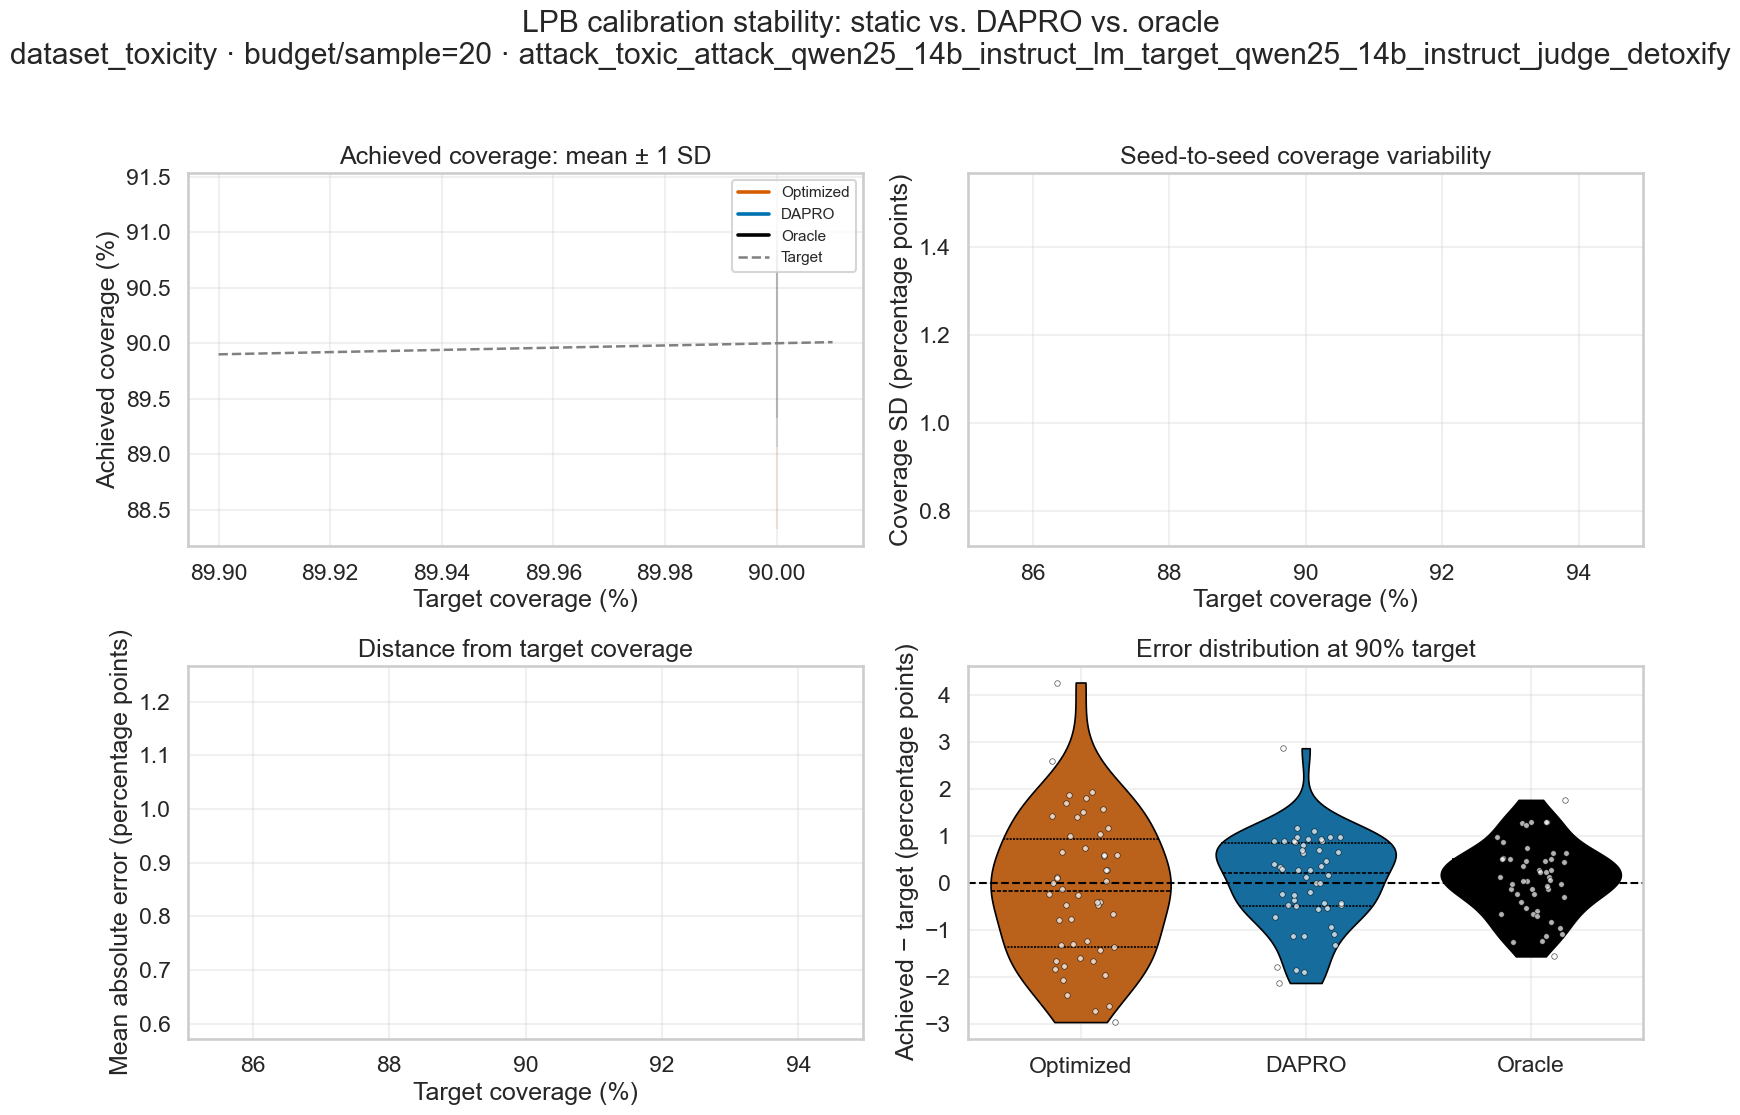

Saved figure to /Users/shai.feldman/Documents/Projects/dapro_rebuttal/notebooks/figures/calibration_results/dataset_toxicity_attack_toxic_attack_qwen25_14b_instruct_lm_target_qwen25_14b_instruct_judge_detoxify_20.0_3000_0.56_10.0/optimized_vs_dapro_vs_oracle_coverage.png


In [20]:
if not analysis_ready:
    print("Comparison figure skipped until all three methods are available.")
else:
    sns.set_theme(style="whitegrid", context="talk")
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    ax_coverage, ax_variance, ax_mae, ax_focus = axes.ravel()

    # Mean achieved coverage and seed-to-seed standard deviation.
    for method in METHOD_ORDER:
        method_stats = target_stats.loc[target_stats["Method"].eq(method)].sort_values("target_coverage")
        x = method_stats["target_coverage_pct"].to_numpy()
        mean = method_stats["mean_coverage_pct"].to_numpy()
        std = method_stats["coverage_std_pp"].to_numpy()
        ax_coverage.plot(x, mean, color=COLORS[method], linewidth=2.6, label=method)
        ax_coverage.fill_between(x, mean - std, mean + std, color=COLORS[method], alpha=0.13)
    target_grid = np.linspace(100 * MIN_TARGET, 100 * MAX_TARGET, 200)
    ax_coverage.plot(target_grid, target_grid, color="gray", linestyle="--", linewidth=1.8, label="Target")
    ax_coverage.set_title("Achieved coverage: mean ± 1 SD")
    ax_coverage.set_xlabel("Target coverage (%)")
    ax_coverage.set_ylabel("Achieved coverage (%)")
    ax_coverage.legend(frameon=True, fontsize=11)

    for method in METHOD_ORDER:
        method_stats = target_stats.loc[target_stats["Method"].eq(method)]
        ax_variance.plot(
            method_stats["target_coverage_pct"], method_stats["coverage_std_pp"],
            color=COLORS[method], linewidth=2.6, label=method,
        )
    ax_variance.set_title("Seed-to-seed coverage variability")
    ax_variance.set_xlabel("Target coverage (%)")
    ax_variance.set_ylabel("Coverage SD (percentage points)")

    for method in METHOD_ORDER:
        method_stats = target_stats.loc[target_stats["Method"].eq(method)]
        ax_mae.plot(
            method_stats["target_coverage_pct"], method_stats["mae_pp"],
            color=COLORS[method], linewidth=2.6, label=method,
        )
    ax_mae.set_title("Distance from target coverage")
    ax_mae.set_xlabel("Target coverage (%)")
    ax_mae.set_ylabel("Mean absolute error (percentage points)")

    focus_df = comparison_df.loc[np.isclose(comparison_df["target_coverage"], FOCUS_TARGET)].copy()
    if focus_df.empty:
        raise ValueError(f"Focus target {FOCUS_TARGET:.0%} is absent from the paired data.")
    sns.violinplot(
        data=focus_df, x="Method", y="Coverage error (pp)", order=METHOD_ORDER,
        palette=COLORS, inner="quartile", cut=0, linewidth=1.2, ax=ax_focus,
    )
    sns.stripplot(
        data=focus_df, x="Method", y="Coverage error (pp)", order=METHOD_ORDER,
        color="white", edgecolor="black", linewidth=0.5, size=4, alpha=0.7, jitter=0.16, ax=ax_focus,
    )
    ax_focus.axhline(0, color="black", linestyle="--", linewidth=1.5)
    ax_focus.set_title(f"Error distribution at {FOCUS_TARGET:.0%} target")
    ax_focus.set_xlabel("")
    ax_focus.set_ylabel("Achieved − target (percentage points)")

    for ax in axes.ravel():
        ax.grid(alpha=0.28)
    setup_label = textwrap.shorten(config["dataset_setup"], width=95, placeholder="…")
    fig.suptitle(
        f"LPB calibration stability: static vs. DAPRO vs. oracle\n"
        f"{config['dataset_name']} · budget/sample={config['budget_per_sample']:.0f} · {setup_label}",
        y=1.02,
    )
    fig.tight_layout()

    figure_dir = PROJECT_ROOT / "notebooks" / "figures" / "calibration_results" / experiment_signature
    figure_dir.mkdir(parents=True, exist_ok=True)
    figure_path = figure_dir / "optimized_vs_dapro_vs_oracle_coverage.png"
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure to {figure_path}")


In [21]:
if not analysis_ready:
    print("Summary table skipped until all three methods are available.")
else:
    focus_summary = (
        target_stats.loc[np.isclose(target_stats["target_coverage"], FOCUS_TARGET)]
        .set_index("Method")
        .reindex(METHOD_ORDER)
    )
    oracle_sd = focus_summary.loc["Oracle", "coverage_std_pp"]
    oracle_mae = focus_summary.loc["Oracle", "mae_pp"]
    focus_summary["SD / oracle"] = focus_summary["coverage_std_pp"] / oracle_sd
    focus_summary["MAE / oracle"] = focus_summary["mae_pp"] / oracle_mae
    focus_summary = focus_summary.rename(columns={
        "mean_coverage_pct": "Mean coverage (%)",
        "coverage_std_pp": "Coverage SD (pp)",
        "bias_pp": "Bias (pp)",
        "mae_pp": "MAE (pp)",
        "rmse_pp": "RMSE (pp)",
        "seeds": "Seeds",
    })[[
        "Mean coverage (%)", "Coverage SD (pp)", "Bias (pp)", "MAE (pp)",
        "RMSE (pp)", "SD / oracle", "MAE / oracle", "Seeds",
    ]]
    display(focus_summary.style.format({
        "Mean coverage (%)": "{:.2f}", "Coverage SD (pp)": "{:.2f}",
        "Bias (pp)": "{:+.2f}", "MAE (pp)": "{:.2f}", "RMSE (pp)": "{:.2f}",
        "SD / oracle": "{:.2f}×", "MAE / oracle": "{:.2f}×", "Seeds": "{:.0f}",
    }))


,Mean coverage (%),Coverage SD (pp),Bias (pp),MAE (pp),RMSE (pp),SD / oracle,MAE / oracle,Seeds
Method,,,,,,,,
Optimized,89.85,1.53,-0.15,1.24,1.52,2.02×,2.05×,50
DAPRO,90.04,0.97,+0.04,0.78,0.96,1.28×,1.30×,50
Oracle,90.08,0.76,+0.08,0.60,0.76,1.00×,1.00×,50


In [22]:
if not analysis_ready:
    print("Paired oracle-distance summary skipped until all three methods are available.")
else:
    oracle_distance = pd.Series({
        "DAPRO": (paired_coverage["DAPRO"] - paired_coverage["Oracle"]).abs().mean(),
        "Optimized": (paired_coverage["Optimized"] - paired_coverage["Oracle"]).abs().mean(),
    }, name="Mean paired distance from oracle (pp)")
    oracle_distance = oracle_distance.reindex(["DAPRO", "Optimized"])
    display(oracle_distance.to_frame().style.format("{:.2f}"))

    if np.isclose(oracle_distance["DAPRO"], 0.0):
        comparison_sentence = (
            f"Across {MIN_TARGET:.0%}–{MAX_TARGET:.0%} targets, DAPRO's mean paired distance "
            f"from the oracle is {oracle_distance['DAPRO']:.2f} pp versus "
            f"{oracle_distance['Optimized']:.2f} pp for the static optimized baseline."
        )
    else:
        ratio = oracle_distance["Optimized"] / oracle_distance["DAPRO"]
        comparison_sentence = (
            f"Across {MIN_TARGET:.0%}–{MAX_TARGET:.0%} targets, the static optimized baseline is "
            f"{ratio:.2f}× farther from the oracle than DAPRO on paired seed-target evaluations."
        )
    summary_rows = [
        "| Method | Mean paired distance from oracle (pp) |",
        "|---|---:|",
        *[f"| {method} | {value:.2f} |" for method, value in oracle_distance.items()],
    ]
    print("```markdown")
    print("\n".join(summary_rows))
    print(f"\n{comparison_sentence}")
    print("```")


,Mean paired distance from oracle (pp)
DAPRO,0.48
Optimized,1.13


```markdown
| Method | Mean paired distance from oracle (pp) |
|---|---:|
| DAPRO | 0.48 |
| Optimized | 1.13 |

Across 90%–90% targets, the static optimized baseline is 2.35× farther from the oracle than DAPRO on paired seed-target evaluations.
```


## Reading the evidence

The intended claim is supported when DAPRO's mean-coverage curve and variability band nearly overlap the oracle, its SD and MAE ratios are close to 1, and its paired distance from the oracle is materially smaller than the optimized baseline's. The notebook reports the observed quantities directly rather than assuming this conclusion.